In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [140]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [141]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Churn Distribution ===")
print(df['Churn'].value_counts())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

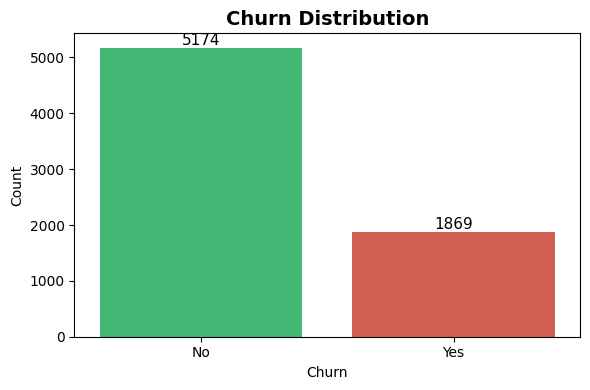

✅ Plot saved!


In [142]:
import os
os.makedirs('../outputs', exist_ok=True)

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/churn_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")

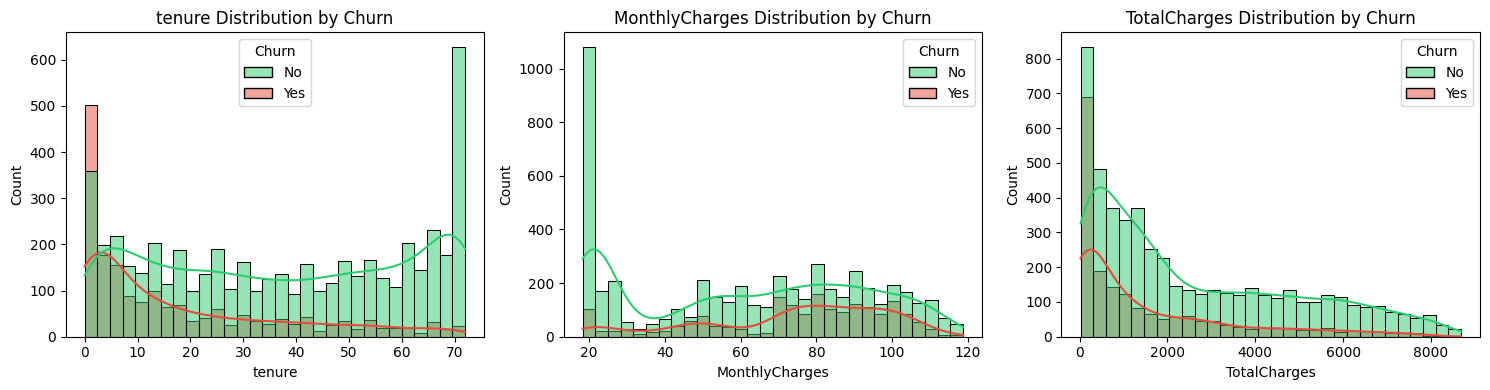

✅ Plot saved!


In [143]:
os.makedirs('../outputs', exist_ok=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', bins=30,
                 palette=['#2ecc71','#e74c3c'], ax=axes[i], kde=True)
    axes[i].set_title(f'{col} Distribution by Churn')
plt.tight_layout()
plt.savefig('../outputs/numerical_distributions.png', dpi=150)
plt.show()
print("✅ Plot saved!")

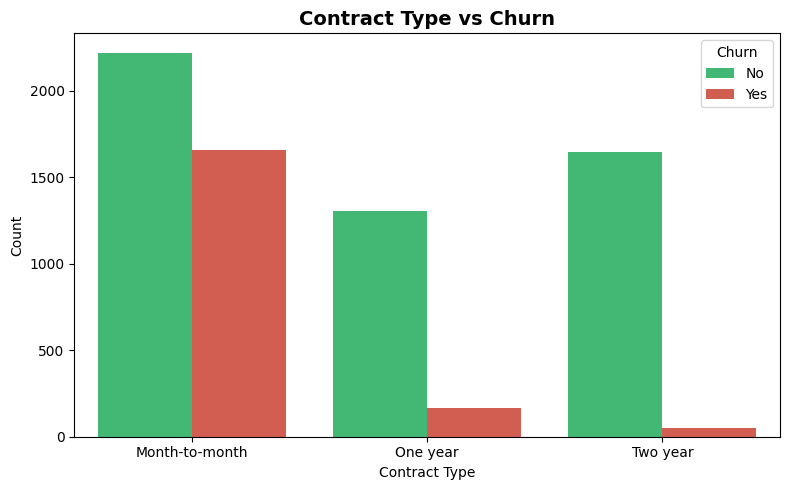

✅ Plot saved!


In [144]:
os.makedirs('../outputs', exist_ok=True)

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Contract Type vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.savefig('../outputs/contract_vs_churn.png', dpi=150)
plt.show()
print("✅ Plot saved!")

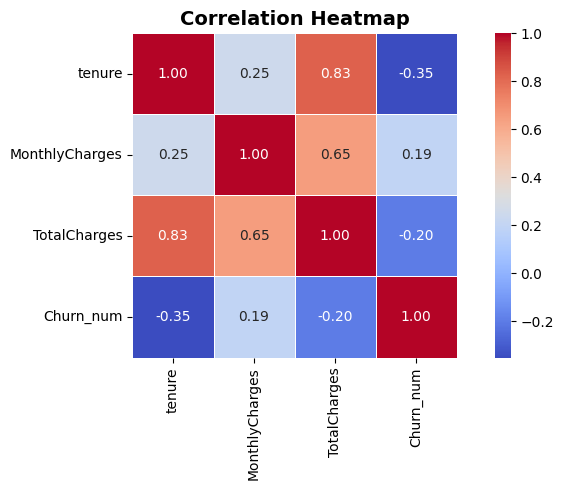

✅ Plot saved!


In [145]:
os.makedirs('../outputs', exist_ok=True)

df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
df_temp['Churn_num'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8,5))
corr = df_temp[['tenure','MonthlyCharges','TotalCharges','Churn_num']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [146]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Step 1: CustomerID drop karo (kaam ka nahi)
df.drop('customerID', axis=1, inplace=True)

# Step 2: TotalCharges ko numeric banao
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 3: Missing values drop karo
df.dropna(inplace=True)

# Step 4: Categorical columns encode karo
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Churn')  # Target column alag rakhenge

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Step 5: Target column encode karo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("✅ Preprocessing done!")
print("Shape after cleaning:", df.shape)
print("\nChurn distribution:\n", df['Churn'].value_counts())

✅ Preprocessing done!
Shape after cleaning: (7032, 20)

Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [147]:
# Features aur Target alag karo
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print("Train set churn distribution:\n", y_train.value_counts())

# SMOTE apply karo — class imbalance fix
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Train set churn distribution:\n", y_train_sm.value_counts())
print("\n✅ SMOTE applied! Training data balanced.")

Before SMOTE:
Train set churn distribution:
 Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Train set churn distribution:
 Churn
0    4130
1    4130
Name: count, dtype: int64

✅ SMOTE applied! Training data balanced.


In [148]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=" * 40)
print("    RANDOM FOREST RESULTS (TUNED)")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"AUC-ROC:   {roc_auc_score(y_test, rf_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("✅ Random Forest trained!")

    RANDOM FOREST RESULTS (TUNED)
Accuracy:  75.98%
AUC-ROC:   0.8163

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1033
           1       0.54      0.62      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407

✅ Random Forest trained!


In [149]:
print(type(X_train_sm))
print(type(y_train_sm))
print(type(X_test))
print(type(y_test))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>
<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [150]:
from xgboost import XGBClassifier

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)

# Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Results
print("=" * 40)
print("      XGBOOST RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"AUC-ROC:   {roc_auc_score(y_test, xgb_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))
print("✅ XGBoost trained!")

      XGBOOST RESULTS
Accuracy:  76.12%
AUC-ROC:   0.8133

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1033
           1       0.55      0.60      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407

✅ XGBoost trained!


In [151]:
import sys
print(sys.executable)

import xgboost
print(xgboost.__version__)

/usr/local/bin/python3
3.2.0


In [152]:
import sys

!{sys.executable} -m pip show xgboost

1383.49s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages
Requires: numpy, scipy
Required-by: 


In [153]:
import sys
!{sys.executable} -m pip install scikit-learn

1389.09s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [154]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [155]:
import xgboost
print(xgboost.__version__)

3.2.0


In [156]:
from xgboost import XGBClassifier
print("XGBoost OK")

XGBoost OK


In [157]:
import sys
!{sys.executable} -m pip install imbalanced-learn

1584.47s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [158]:
from imblearn.over_sampling import SMOTE
print("SMOTE OK")

SMOTE OK


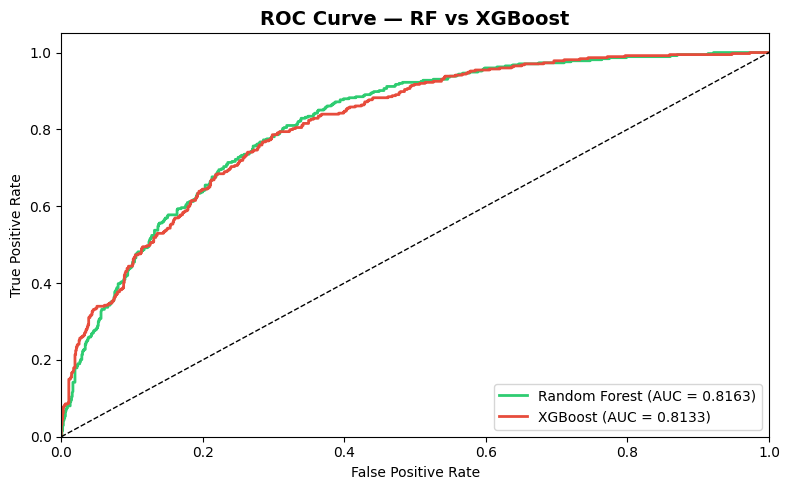

✅ ROC Curve saved!


In [159]:
os.makedirs('../outputs', exist_ok=True)

# ROC Curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(8, 5))
plt.plot(rf_fpr, rf_tpr, color='#2ecc71', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(xgb_fpr, xgb_tpr, color='#e74c3c', lw=2,
         label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — RF vs XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png', dpi=150)
plt.show()
print("✅ ROC Curve saved!")

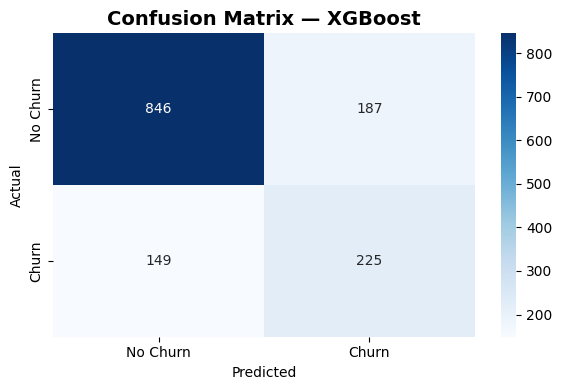

✅ Confusion Matrix saved!


In [160]:
os.makedirs('../outputs', exist_ok=True)

cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saved!")

Background dataset has 8260 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8260 when initializing the masker.


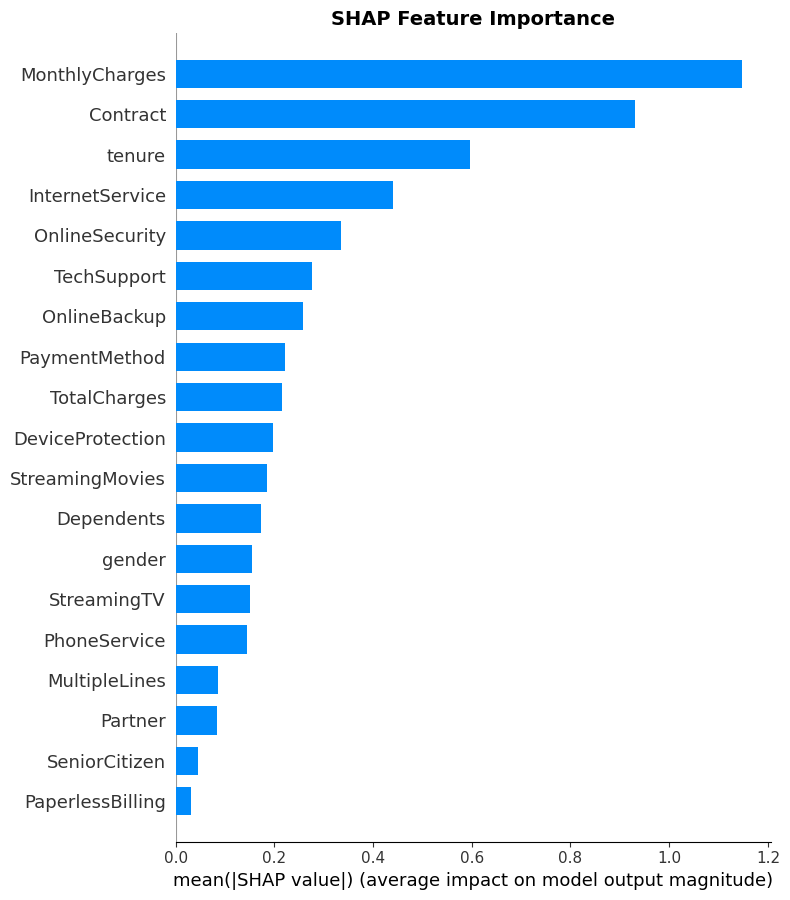

✅ SHAP Bar plot saved!


In [165]:
import os
import shap
import matplotlib.pyplot as plt
os.makedirs('../outputs', exist_ok=True)

# SHAP Explainer banao XGBoost ke liye
explainer = shap.Explainer(xgb_model, X_train_sm)
shap_values = explainer(X_test)

# Plot 1 — Summary Plot (Bar)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Bar plot saved!")








In [166]:
import sys
!{sys.executable} -m pip install shap

63006.88s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [167]:
import shap
print(shap.__version__)

0.52.0


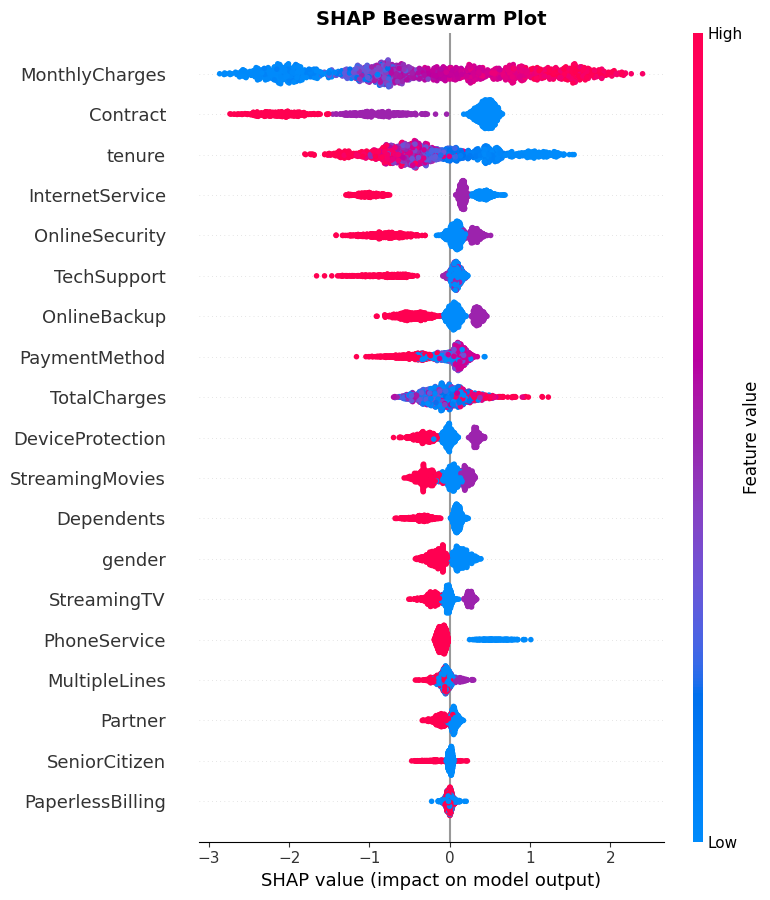

✅ SHAP Beeswarm plot saved!


In [168]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Beeswarm plot saved!")

In [169]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Models save karo
joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(xgb_model, '../models/xgboost_model.pkl')

print("✅ Models saved!")
print("📁 Location: models/")

✅ Models saved!
📁 Location: models/


In [170]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("=" * 50)
print("   CUSTOMER CHURN PREDICTION — FINAL RESULTS")
print("=" * 50)

print("\n📊 RANDOM FOREST:")
print(f"   Accuracy  : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"   AUC-ROC   : {roc_auc_score(y_test, rf_prob):.4f}")
print(f"   F1-Score  : {f1_score(y_test, rf_pred):.4f}")
print(f"   Precision : {precision_score(y_test, rf_pred):.4f}")
print(f"   Recall    : {recall_score(y_test, rf_pred):.4f}")

print("\n📊 XGBOOST:")
print(f"   Accuracy  : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"   AUC-ROC   : {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"   F1-Score  : {f1_score(y_test, xgb_pred):.4f}")
print(f"   Precision : {precision_score(y_test, xgb_pred):.4f}")
print(f"   Recall    : {recall_score(y_test, xgb_pred):.4f}")

print("\n✅ Project Complete!")
print("=" * 50)

   CUSTOMER CHURN PREDICTION — FINAL RESULTS

📊 RANDOM FOREST:
   Accuracy  : 75.98%
   AUC-ROC   : 0.8163
   F1-Score  : 0.5775
   Precision : 0.5423
   Recall    : 0.6176

📊 XGBOOST:
   Accuracy  : 76.12%
   AUC-ROC   : 0.8133
   F1-Score  : 0.5725
   Precision : 0.5461
   Recall    : 0.6016

✅ Project Complete!
